# 06 Model Evaluation and Interpretation

This notebook evaluates the competing models against the stakeholder goal of identifying likely inspections and interprets the strongest drivers of inspection likelihood.

In [4]:
# Author: Jessica
# Importing pandas to load saved results

import pandas as pd

importance = pd.read_csv("shared_data/feature_importance.csv")

print(importance)

                      feature  coefficient
0      prior_inspection_count     0.429642
1         critical_violations     0.364306
2            total_violations     0.164942
3        historical_avg_score     0.031999
4            inspection_month     0.027930
5  score_change_from_previous     0.009327
6  days_since_last_inspection    -0.000755
7             inspection_year    -0.001024
8     historical_avg_critical    -0.344808


In [5]:
# Author: Jessica
# Loading saved model outputs so this notebook runs independently

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

model_results = pd.read_csv("shared_data/model_results_summary.csv")
importance = pd.read_csv("shared_data/feature_importance.csv")
predictions_df = pd.read_csv("shared_data/model_predictions.csv")

print(model_results)
importance.head()

                          Model  Accuracy  Precision_Inspection  \
0           Logistic Regression      0.80                  0.58   
1  Balanced Logistic Regression      0.74                  0.44   
2                 Random Forest      0.84                  0.67   

   Recall_Inspection  F1_Inspection  
0               0.24           0.34  
1               0.69           0.54  
2               0.50           0.58  


,feature,coefficient
0,prior_inspection_count,0.429642
1,critical_violations,0.364306
2,total_violations,0.164942
3,historical_avg_score,0.031999
4,inspection_month,0.027930


Baseline model has 80% accuracy but low recall (24%) for inspections, meaning it misses many actual inspections so improving recall is a priority

Using class weighting improves recall for inspections (24% → 69%), meaning the model now captures most inspections even with a slight drop in accuracy

Random Forest improves overall accuracy and precision, but balanced logistic regression performs better at identifying inspections, which aligns more with our goal

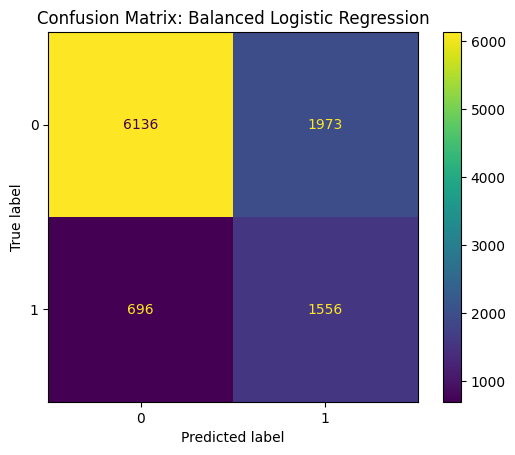

In [9]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

predictions_df = pd.read_csv("shared_data/model_predictions.csv")

cm = confusion_matrix(
    predictions_df['y_test'],
    predictions_df['balanced_logistic_pred']
)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix: Balanced Logistic Regression")
plt.show()

The confusion matrix shows the model captures most inspection cases while allowing some false positives, which is acceptable since the goal is to help restaurants prepare for potential inspections

In [6]:
# Author: Jessica
# Loading feature importance from modeling notebook so this notebook runs independently

import pandas as pd

importance = pd.read_csv("shared_data/feature_importance.csv")

print(importance)

                      feature  coefficient
0      prior_inspection_count     0.429642
1         critical_violations     0.364306
2            total_violations     0.164942
3        historical_avg_score     0.031999
4            inspection_month     0.027930
5  score_change_from_previous     0.009327
6  days_since_last_inspection    -0.000755
7             inspection_year    -0.001024
8     historical_avg_critical    -0.344808


Prior inspections and recent violations are the strongest drivers of future inspections, suggesting inspection decisions are based more on recent activity than long-term trends

## Confusion Matrix for Random Forest

We're running a confusion matrix for a random forest classifier

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict with trained Random Forest model
y_pred_rf = rf_model.predict(X_test)

# Build confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Random Forest Confusion Matrix:\n", cm_rf)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot(cmap="Blues", values_format="d")
plt.title("Random Forest Confusion Matrix")
plt.show()

ModuleNotFoundError: No module named 'sklearn'